In [1]:
import os
import sys
# from don import DeepONet

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile
import matplotlib.pyplot as plt

import json, time, tempfile

import pickle

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

DTYPE = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
fname_ls = ['don_s8_t1_siren_soap', 'don_s8_t1_siren_soap_bsp', 
            'dok7_s8_t1_soap', 'dok7_s8_t1_soap_bsp', 
            'fno_s8_t1_soap', 'fno_s8_t1_soap_bsp', 
            'cno_s8_t1_soap', 'cno_s8_t1_soap_bsp', 'cno_s8_t1_adam']

title_ls = ['DeepONet', 'DeepONet (BSP)', 
            'DeepOKan', 'DeepOKan (BSP)', 
            'FNO', 'FNO (BSP)', 
            'CNO', 'CNO (BSP)',
            'CNO Adam']

# Collecting Fields

In [3]:
true = np.load('don_s8_t1_siren_soap/TEST_TRUE.npy')
print(f"true: {true.shape}")
TRUE = true

field_ls = [true]

for i in range(len(fname_ls)):
    pred = np.load(f"{fname_ls[i]}/TEST_PRED.npy")
    field_ls.append(pred)
    print(f"{fname_ls[i]}: {pred.shape}")

true: (100, 1, 128, 256)
don_s8_t1_siren_soap: (100, 1, 128, 256)
don_s8_t1_siren_soap_bsp: (100, 1, 128, 256)
dok7_s8_t1_soap: (100, 1, 128, 256)
dok7_s8_t1_soap_bsp: (100, 1, 128, 256)
fno_s8_t1_soap: (100, 1, 128, 256)
fno_s8_t1_soap_bsp: (100, 1, 128, 256)
cno_s8_t1_soap: (100, 1, 128, 256)
cno_s8_t1_soap_bsp: (100, 1, 128, 256)
cno_s8_t1_adam: (100, 1, 128, 256)


In [4]:
sample_id = 0

TITLE_LS = ['True', 
            'DeepONet', 'DeepONet (BSP)', 
            'DeepOKan', 'DeepOKan (BSP)', 
            'FNO', 'FNO (BSP)', 
            'CNO', 'CNO (BSP)',
            'CNO Adam']

# Collecting Energy Spectrum

In [5]:
def compute_tke_spectrum_timeseries_torch(u_all, lx=3.2, ly=6.4, smooth=False, device='cpu'):
    u_all = torch.tensor(u_all, dtype=DTYPE, device=device)#.unsqueeze(1)  # [time, 1, nx, ny]
    ntime, nf, nx, ny = u_all.shape

    ntot = nx * ny

    # FFT
    uh_all = torch.fft.fftn(u_all, dim=(-2, -1)) / ntot  # [1, ntime, nx, ny]

    # Compute energy: sum of squares of real and imaginary parts
    energy = 0.5 * (uh_all.real**2 + uh_all.imag**2).sum(dim=1)  # [ntime, nx, ny]
    # energy = torch.sqrt(energy)

    # Wavenumber grids
    kx = 2*np.pi * torch.fft.fftfreq(nx, d=lx / nx, device=device)
    ky = 2*np.pi * torch.fft.fftfreq(ny, d=ly / ny, device=device)
    # kz = torch.fft.fftfreq(nz, d=lz / nz, device=device)
    KX, KY = torch.meshgrid(kx, ky, indexing='ij')
    K_mag = torch.sqrt(KX**2 + KY**2 )  # [nx, ny, nz]

    # Flatten for binning
    # k_bins = torch.round(K_mag.flatten() / K_mag.max() * (nx // 2)).to(torch.int64)  # [npts]
    # max_bin = k_bins.max().item() + 1

    # wave_numbers = torch.arange(max_bin, device=device) #* (2 * np.pi / ((lx + ly)/2))

    kmax = 2*np.pi * max((nx/2)/(lx), (ny/2)/(ly))
    kmin = 2*np.pi * 1/( (lx**2 + ly**2)**0.5 )

    nbins = ny//2 + 1

    dk = (kmax - kmin)/(nbins - 1)

    wave_numbers = torch.linspace(kmin, kmax, nbins, device=device)
    k_bins = K_mag.flatten()

    # Flatten energy: [ntime, npts]
    energy_flat = energy.view(ntime, -1)  # [ntime, npts]

    # Allocate spectrum
    tke_spectrum = torch.zeros(ntime, nbins - 1, device=device)

    # print(f"k_bins: {k_bins.shape}")
    # print(f"wave_numbers: {wave_numbers.shape}")

    # Vectorized binning using broadcasting + scatter_add
    for k in range(nbins - 1):
        lo = wave_numbers[k]
        hi = wave_numbers[k+1]
        mask = (k_bins >= lo) & (k_bins < hi)
        # mask = (k_bins == wave_numbers[k]) # and k_bins < wave_numbers[k+1])
        if mask.any():
            tke_spectrum[:, k] = energy_flat[:, mask].sum(dim=1)

    # if smooth:
    #     kernel = torch.ones(5, device=device) / 5
    #     kernel = kernel[None, None, :]
    #     tke_spectrum = torch.nn.functional.conv1d(
    #         tke_spectrum[:, None, :], kernel, padding=2
    #     ).squeeze(1)

    knyquist = (2 * np.pi / ((lx + ly )/2)) * min(nx, ny) / 2

    wave_numbers_center = wave_numbers[:-1] + dk/2 
    tke_spectrum = tke_spectrum * nbins

    return knyquist, wave_numbers_center.detach().cpu().numpy(), tke_spectrum.detach().cpu().numpy()  # [ntime, maxbin]

spec_ls = []
for i in range(len(field_ls)):
    field = field_ls[i]
    with torch.no_grad():
        _, wn, spec = compute_tke_spectrum_timeseries_torch(field)

    print(f"wn: {wn.shape}, spec: {spec.shape}")
    spec_ls.append(spec)

wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)
wn: (128,), spec: (100, 128)


# Collecting Grad and Laplacian

In [6]:
def grad_l1(u: torch.Tensor,
            hx: float = 3.2/128,
            hy: float = 6.4/256,
            padding_mode: str = "circular") -> torch.Tensor:
    """
    Compute |du/dx| + |du/dy| for u of shape [BS, 1, Nx, Ny].

    Central differences with periodic padding by default.
    """

    u = torch.tensor(u)
    assert u.ndim == 4 and u.size(1) == 1, "u must have shape [BS, 1, Nx, Ny]"

    device, dtype = u.device, u.dtype

    # central difference: df/dx ≈ (f(x+h) - f(x-h)) / (2h)
    kx = torch.tensor([[0.0,  0.0, 0.0],
                       [-0.5, 0.0, 0.5],
                       [0.0,  0.0, 0.0]], device=device, dtype=dtype).view(1, 1, 3, 3)

    ky = torch.tensor([[0.0, -0.5, 0.0],
                       [0.0,  0.0, 0.0],
                       [0.0,  0.5, 0.0]], device=device, dtype=dtype).view(1, 1, 3, 3)

    u_padded = F.pad(u, (1, 1, 1, 1), mode=padding_mode)

    du_dx = F.conv2d(u_padded, kx, padding=0) / hx
    du_dy = F.conv2d(u_padded, ky, padding=0) / hy

    return du_dx.abs().detach().cpu().numpy() + du_dy.abs().detach().cpu().numpy()


def laplacian(u: torch.Tensor,
              hx: float = 3.2/128,
              hy: float = 6.4/256,
              padding_mode: str = "circular") -> torch.Tensor:
    """
    Compute d^2u/dx^2 + d^2u/dy^2 for u of shape [BS, 1, Nx, Ny].

    Uses standard 5-point stencil via second derivatives in x and y.
    """

    u = torch.tensor(u)
    assert u.ndim == 4 and u.size(1) == 1, "u must have shape [BS, 1, Nx, Ny]"

    device, dtype = u.device, u.dtype

    # second derivative in x: f''(x) ≈ (f(x+h) - 2f(x) + f(x-h)) / h^2
    kxx = torch.tensor([[0.0,  0.0, 0.0],
                        [1.0, -2.0, 1.0],
                        [0.0,  0.0, 0.0]], device=device, dtype=dtype).view(1, 1, 3, 3)

    # second derivative in y
    kyy = torch.tensor([[0.0, 1.0, 0.0],
                        [0.0, -2.0, 0.0],
                        [0.0, 1.0, 0.0]], device=device, dtype=dtype).view(1, 1, 3, 3)

    u_padded = F.pad(u, (1, 1, 1, 1), mode=padding_mode)

    d2u_dx2 = F.conv2d(u_padded, kxx, padding=0) / (hx ** 2)
    d2u_dy2 = F.conv2d(u_padded, kyy, padding=0) / (hy ** 2)

    return (d2u_dx2 + d2u_dy2).detach().cpu().numpy()

grad_ls = [grad_l1(field) for field in field_ls]
lapl_ls = [laplacian(field) for field in field_ls]

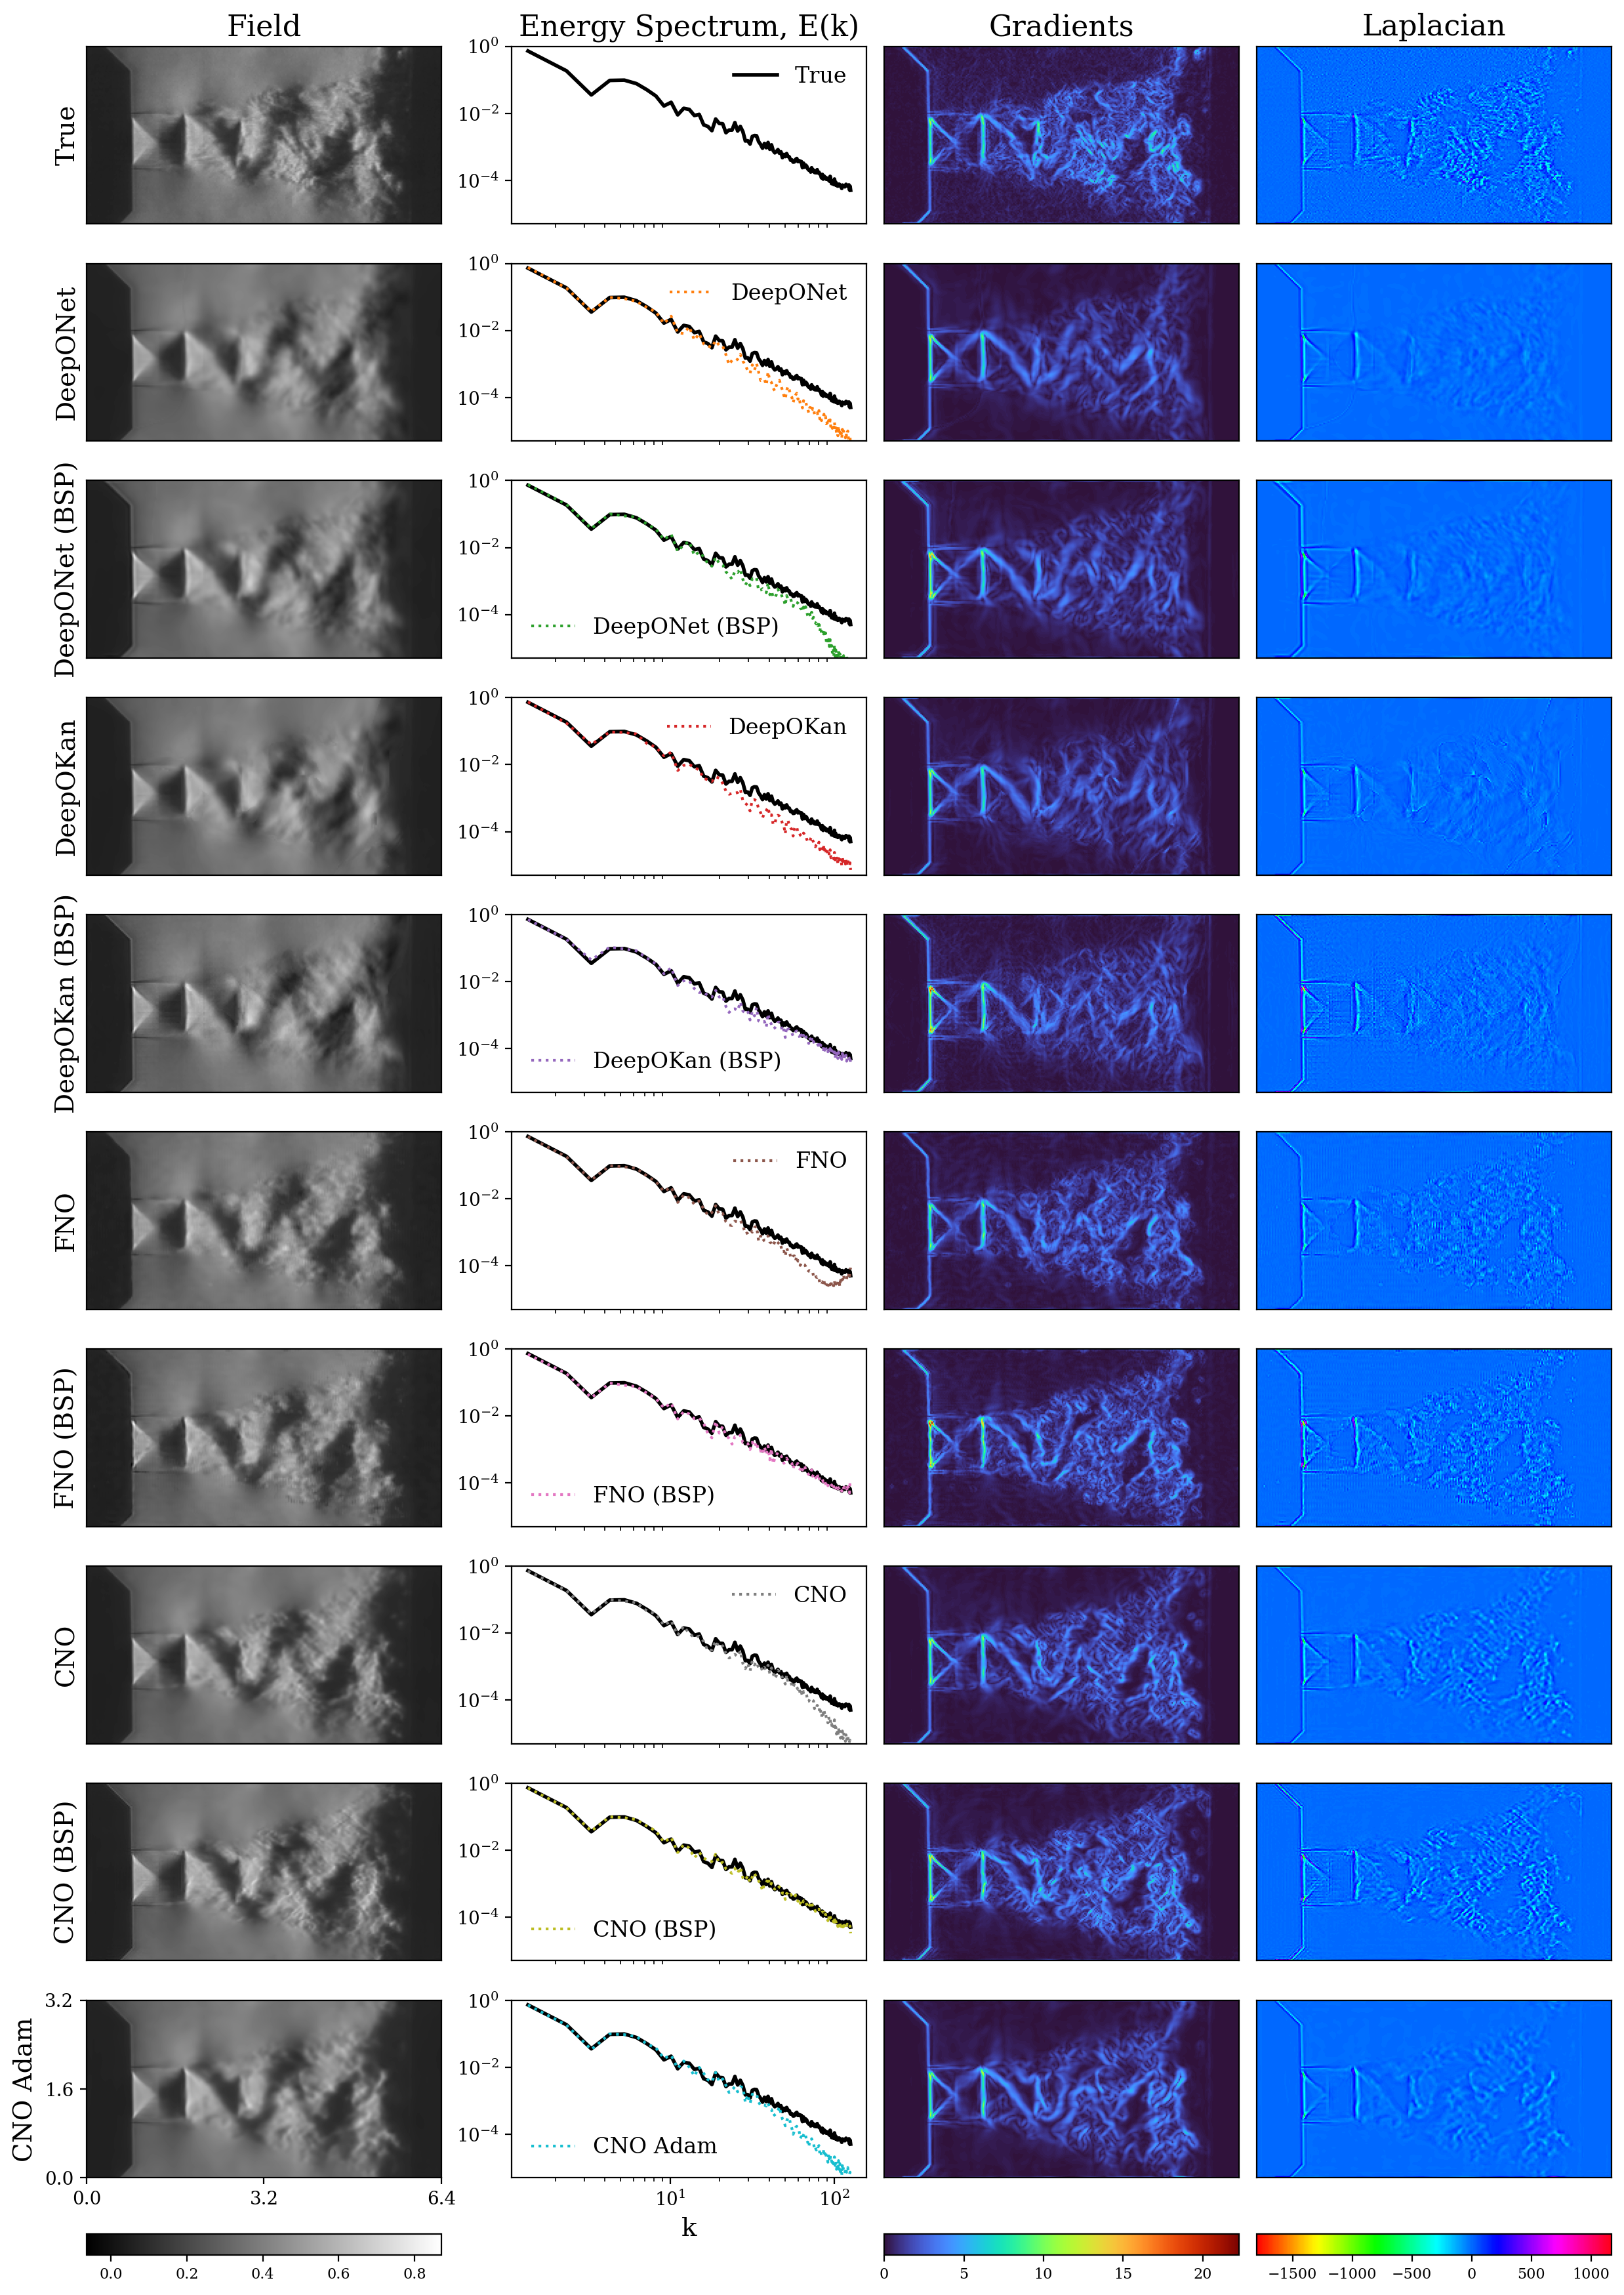

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def _to_numpy(x):
    if hasattr(x, "detach"):  # torch tensor
        x = x.detach().cpu().numpy()
    return np.asarray(x)

def plot_field_spec_grad_lapl_grid_v2(
    field_ls, spec_ls, grad_ls, lapl_ls,
    wn, TITLE_LS,
    sample_id=0,
    true_idx=0,                  # assuming row 0 is "true"
    figsize=None,
    extent=(0.0, 6.4, 0.0, 3.2),
    x_ticks=(0.0, 3.2, 6.4),
    y_ticks=(0.0, 1.6, 3.2),
    spacer_w=0.28,               # gap between col1 and col2
    spacer_h=0.18,               # gap between last row and colorbars
    wspace=0.06, hspace=0.06,
    legend_kwargs=None,
):
    """
    Visible columns: [Field, Spectrum, Gradients, Laplacian]
    Internally uses an extra spacer column between Field and Spectrum.
    Also uses an extra spacer row above the colorbars.
    """

    n = len(field_ls)
    assert len(spec_ls) == n and len(grad_ls) == n and len(lapl_ls) == n and len(TITLE_LS) == n

    wn = _to_numpy(wn).reshape(-1)

    # Shared vmin/vmax for image columns (at this sample_id across all rows)
    field_stack = np.stack([_to_numpy(field_ls[i][sample_id, 0]) for i in range(n)], axis=0)
    grad_stack  = np.stack([_to_numpy(grad_ls[i][sample_id, 0])  for i in range(n)], axis=0)
    lapl_stack  = np.stack([_to_numpy(lapl_ls[i][sample_id, 0])  for i in range(n)], axis=0)

    norm_f = mpl.colors.Normalize(vmin=float(field_stack.min()), vmax=float(field_stack.max()))
    norm_g = mpl.colors.Normalize(vmin=float(grad_stack.min()),  vmax=float(grad_stack.max()))
    norm_l = mpl.colors.Normalize(vmin=float(lapl_stack.min()),  vmax=float(lapl_stack.max()))

    if figsize is None:
        # Roughly consistent with width ratios + n rows
        figsize = (15, max(2.2 * n, 4.2))

    # 5 columns: [Field, SPACER, Spectrum, Grad, Lapl]
    # widths: image cols 2, spectrum 1, spacer small
    width_ratios = [2.0, spacer_w, 2.0, 2.0, 2.0]

    # rows: n plot rows + spacer row + colorbar row
    height_ratios = [1.0] * n + [spacer_h] + [0.10]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=n + 2, ncols=5,
        width_ratios=width_ratios,
        height_ratios=height_ratios,
        wspace=wspace, hspace=hspace
    )

    # Visible axes holders: (n,4) corresponding to [Field, Spectrum, Grad, Lapl]
    axs = np.empty((n, 4), dtype=object)

    # Build axes row by row
    for r in range(n):
        ax_field = fig.add_subplot(gs[r, 0])
        ax_sp    = fig.add_subplot(gs[r, 1]); ax_sp.axis("off")  # spacer col
        ax_spec  = fig.add_subplot(gs[r, 2])
        ax_grad  = fig.add_subplot(gs[r, 3])
        ax_lapl  = fig.add_subplot(gs[r, 4])

        axs[r, 0] = ax_field
        axs[r, 1] = ax_spec
        axs[r, 2] = ax_grad
        axs[r, 3] = ax_lapl

        # Enforce box shapes: image columns are 2x wider than tall => height/width = 0.5
        ax_field.set_box_aspect(0.5)
        ax_grad.set_box_aspect(0.5)
        ax_lapl.set_box_aspect(0.5)

        # Spectrum is square => height/width = 1
        ax_spec.set_box_aspect(0.5)

    # Spacer row (above colorbars)
    for c in range(5):
        ax = fig.add_subplot(gs[n, c])
        ax.axis("off")

    # Colorbar row: under Field, Grad, Lapl (leave spectrum blank + spacer blank)
    cax_f  = fig.add_subplot(gs[n + 1, 0])
    cax_sp = fig.add_subplot(gs[n + 1, 1]); cax_sp.axis("off")
    cax_blank_spec = fig.add_subplot(gs[n + 1, 2]); cax_blank_spec.axis("off")
    cax_g  = fig.add_subplot(gs[n + 1, 3])
    cax_l  = fig.add_subplot(gs[n + 1, 4])

    # Column titles on first row (visible cols only)
    col_titles = ["Field", "Energy Spectrum, E(k)", "Gradients", "Laplacian"]
    for c in range(4):
        axs[0, c].set_title(col_titles[c], fontsize=16)

    # Legend styling
    if legend_kwargs is None:
        legend_kwargs = dict(loc="best", fontsize=12, frameon=False)

    # Precompute "true" spectrum once
    y_true = _to_numpy(spec_ls[true_idx])
    if y_true.ndim == 2:
        y_true = y_true[sample_id]
    y_true = y_true.reshape(-1)

    # Plot
    for r in range(n):
        # ---- Col 1: Field ----
        arr_f = np.fliplr(_to_numpy(field_ls[r][sample_id, 0]))
        axs[r, 0].imshow(arr_f, cmap="gray", norm=norm_f,
                         origin="lower", extent=extent, aspect="auto")
        axs[r, 0].set_ylabel(TITLE_LS[r], fontsize=14)

        # ticks for images: x only last row; y only first column (so keep y here)
        if r == n - 1:
            axs[r, 0].set_xticks(x_ticks)
            axs[r, 0].set_yticks(y_ticks)
        else:
            axs[r, 0].set_xticks([])
            axs[r, 0].set_yticks([])

        # ---- Col 2: Spectrum (square) ----
        y = _to_numpy(spec_ls[r])
        if y.ndim == 2:
            y = y[sample_id]
        y = y.reshape(-1)

        # mask for loglog
        mask_true = (wn > 0) & (y_true > 0)
        mask_pred = (wn > 0) & (y > 0)

        # plot true every row, but only label it in first row
        true_label = TITLE_LS[true_idx] if r == true_idx else "_nolegend_"
        axs[r, 1].loglog(wn[mask_true], y_true[mask_true], lw=2.0, ls="-", color="k", label=true_label)
        axs[r, 1].set_ylim(5*10**-6, 10**0)

        # plot current row's spectrum
        if r == true_idx:
            # first row: only "true" in legend; don't add duplicate
            pass
        else:
            axs[r, 1].loglog(wn[mask_pred], y[mask_pred], lw=1.5, ls=":", color=f"C{r}", label=TITLE_LS[r])
            # axs[r, 1].set_ylabel('E(k)', fontsize=14)

        # x ticks only last row; xlabel only last row
        if r == n - 1:
            axs[r, 1].set_xlabel("k", fontsize=14)
        else:
            axs[r, 1].set_xticks([])

        # show legend: row 0 shows True; rows 1.. show only that row's label
        axs[r, 1].legend(**legend_kwargs)

        # ---- Col 3: Gradients ----
        arr_g = np.fliplr(_to_numpy(grad_ls[r][sample_id, 0]))
        axs[r, 2].imshow(arr_g, cmap="turbo", norm=norm_g,
                         origin="lower", extent=extent, aspect="auto")

        if r == n - 1:
            axs[r, 2].set_xticks([])
        else:
            axs[r, 2].set_xticks([])
        axs[r, 2].set_yticks([])

        # ---- Col 4: Laplacian ----
        arr_l = np.fliplr(_to_numpy(lapl_ls[r][sample_id, 0]))
        axs[r, 3].imshow(arr_l, cmap="hsv", norm=norm_l,
                         origin="lower", extent=extent, aspect="auto")

        if r == n - 1:
            axs[r, 3].set_xticks([])
        else:
            axs[r, 3].set_xticks([])
        axs[r, 3].set_yticks([])

    # Colorbars (horizontal) under last row, with shared norms
    sm_f = mpl.cm.ScalarMappable(norm=norm_f, cmap="gray");  sm_f.set_array([])
    sm_g = mpl.cm.ScalarMappable(norm=norm_g, cmap="turbo"); sm_g.set_array([])
    sm_l = mpl.cm.ScalarMappable(norm=norm_l, cmap="hsv");   sm_l.set_array([])

    cb_f = fig.colorbar(sm_f, cax=cax_f, orientation="horizontal")
    cb_g = fig.colorbar(sm_g, cax=cax_g, orientation="horizontal")
    cb_l = fig.colorbar(sm_l, cax=cax_l, orientation="horizontal")

    for cb in (cb_f, cb_g, cb_l):
        cb.ax.tick_params(labelsize=8)

    return fig, axs

# Example:
fig, axs = plot_field_spec_grad_lapl_grid_v2(
    field_ls, spec_ls, grad_ls, lapl_ls,
    wn=wn, TITLE_LS=TITLE_LS,
    sample_id=0, true_idx=0,
    spacer_w=0.20, spacer_h=0.1
)
plt.show()


# Print Errors

In [10]:
# Barron norm
def get_barron_norm(u_all, alpha=0, lx=3.2, ly=6.4, smooth=False, alpha0=0):
    u_all = torch.tensor(u_all, dtype=DTYPE, device=device)#.unsqueeze(1)  # [time, 1, nx, ny]
    ntime, nf, nx, ny = u_all.shape

    ntot = nx * ny

    # FFT
    uh_all = torch.fft.fftn(u_all, dim=(-2, -1)) / ntot  # [1, ntime, nx, ny]

    # Compute energy: sum of squares of real and imaginary parts
    energy = ( 0.5 * (uh_all.real**2 + uh_all.imag**2).sum(dim=1))  # [ntime, nx, ny]
    # energy = torch.sqrt(energy)

    # Wavenumber grids
    kx = 2*np.pi * torch.fft.fftfreq(nx, d=lx / nx, device=device)
    ky = 2*np.pi * torch.fft.fftfreq(ny, d=ly / ny, device=device)
    # kz = torch.fft.fftfreq(nz, d=lz / nz, device=device)
    KX, KY = torch.meshgrid(kx, ky, indexing='ij')
    K_mag = torch.sqrt(KX**2 + KY**2 )  # [nx, ny, nz]

    kmax = 2*np.pi * max((nx/2)/(lx), (ny/2)/(ly))
    kmin = 2*np.pi * 1/( (lx**2 + ly**2)**0.5 )

    nbins = ny//2 + 1

    dk = (kmax - kmin)/(nbins - 1)

    wave_numbers = torch.linspace(kmin, kmax, nbins, device=device)
    k_bins = K_mag.flatten()

    energy = (energy**0.5) * K_mag

    # Flatten energy: [ntime, npts]
    energy_flat = energy.view(ntime, -1)  # [ntime, npts]

    # Allocate spectrum
    barron_norm = torch.zeros(ntime, nbins - 1, device=device)

    # Vectorized binning using broadcasting + scatter_add
    for k in range(nbins - 1):
        lo = wave_numbers[k]
        hi = wave_numbers[k+1]
        mask = (k_bins >= lo) & (k_bins < hi)
        # mask = (k_bins == wave_numbers[k]) # and k_bins < wave_numbers[k+1])
        if mask.any():
            barron_norm[:, k] = energy_flat[:, mask].sum(dim=1)


    barron_norm = barron_norm * nbins

    return barron_norm.detach().cpu().numpy()  # [ntime, maxbin]
    
    # u_all = torch.tensor(u_all, dtype=DTYPE, device=device)#.unsqueeze(1)  # [time, 1, nx, ny]
    # ntime, nf, nx, ny = u_all.shape

    # ny_h = ny//2 + 1

    

    # ntot = nx * ny / (2**0.5)

    # # FFT
    # uh_all = torch.fft.rfftn(u_all, dim=(-2, -1)) #/ ntot  # [1, ntime, nx, ny]

    # # Compute energy: sum of squares of real and imaginary parts
    # # energy = 0.5 * (uh_all.real**2 + uh_all.imag**2).sum(dim=1)  # [ntime, nx, ny]
    # # energy = torch.sqrt(energy)

    # # Wavenumber grids
    # kx = 2*np.pi * torch.fft.fftfreq(nx, d=lx / nx, device=device)
    # ky = 2*np.pi * torch.fft.rfftfreq(ny, d=ly / ny, device=device)
    # # kz = torch.fft.fftfreq(nz, d=lz / nz, device=device)
    # KX, KY = torch.meshgrid(kx, ky, indexing='ij')
    # K_mag = torch.sqrt(KX**2 + KY**2 )  # [nx, ny, nz]

    # filter = torch.zeros_like(K_mag)
    # filter[K_mag>0] = K_mag[K_mag>0] #** (-alpha0 + alpha)

    # uh_new = uh_all*filter #/(torch.std(filter)**(alpha/2))

    # u = torch.fft.irfftn(uh_new, s=(nx,ny), dim=(-2,-1))  # [B,3,Nx,Ny,Nz], real by construction

    # return u.detach().cpu().numpy()

def get_err(T, P, kind="minmax", eps=1e-12):
    MIN = np.min(T) #min(np.min(T), np.min(P))
    MAX = np.max(T) #max(np.max(T), np.max(P))
    MEAN = np.mean(T)
    STD  = np.std(T)
    if kind=="minmax":
        shift = MIN
        scale = MAX-MIN
    elif kind=="meanstd":
        shift=MEAN
        scale=STD
    elif kind=="zeroone":
        shift=0
        scale=1
        

    T = (T-shift)/scale
    P = (P-shift)/scale

    # bs = T.shape[0]
    # T = T.reshape(bs,-1)
    # P = P.reshape(bs,-1)
    # diff = P - T
    # num = np.sqrt(np.sum(diff**2, axis=(1)))   # (BS,)
    # den = np.sqrt(np.sum(T**2,    axis=(1)))   # (BS,)
    # rel = num / (den + eps)                        # (BS,)
    # return rel.mean()
    
    # return np.mean(  np.sqrt(np.mean( (T-P)**2, axis=(2,3) ))  )
    return  np.mean( (T-P)**2 )**0.5

barron_ls = []
for i in range(len(field_ls)):
    field = field_ls[i]
    with torch.no_grad():
        barron = get_barron_norm(field)
    barron_ls.append(barron)

field_error_ls  = []
spec_error_ls   = []
barron_error_ls = []

for i in range(1, len(field_ls), 1):
    true = field_ls[0]
    pred = field_ls[i]
    field_error_ls.append(get_err(true, pred))

    true = spec_ls[0]
    pred = spec_ls[i]
    spec_error_ls.append(get_err(np.log10(true), np.log10(pred) ))

    true = barron_ls[0]
    pred = barron_ls[i]
    barron_error_ls.append(get_err(true, pred))

print(title_ls)
print(f"field  error:\n{field_error_ls}")
print(f"spec   error:\n{spec_error_ls}")
print(f"barron error:\n{barron_error_ls}")

['DeepONet', 'DeepONet (BSP)', 'DeepOKan', 'DeepOKan (BSP)', 'FNO', 'FNO (BSP)', 'CNO', 'CNO (BSP)', 'CNO Adam']
field  error:
[0.0528675490559058, 0.05346057585664029, 0.05380688680167179, 0.05472072162744275, 0.051655643767228254, 0.05564343965543578, 0.051175110019462844, 0.054252068210024755, 0.05160355297338639]
spec   error:
[0.15664249832859614, 0.1674673503486954, 0.12891573582050966, 0.04159567868572828, 0.086549823453362, 0.02560328980790852, 0.11721522082841072, 0.02110850796967819, 0.13942960118654296]
barron error:
[0.4171483196476637, 0.40834893355769214, 0.3659369091938048, 0.16615733661909723, 0.26409691354998416, 0.08279402072325463, 0.3229241780463674, 0.07917998688353749, 0.3796649494460247]


In [12]:
for err in field_error_ls:
    print(err)

0.0528675490559058
0.05346057585664029
0.05380688680167179
0.05472072162744275
0.051655643767228254
0.05564343965543578
0.051175110019462844
0.054252068210024755
0.05160355297338639


In [13]:
for err in spec_error_ls:
    print(err)

0.15664249832859614
0.1674673503486954
0.12891573582050966
0.04159567868572828
0.086549823453362
0.02560328980790852
0.11721522082841072
0.02110850796967819
0.13942960118654296


In [14]:
for err in barron_error_ls:
    print(err)

0.4171483196476637
0.40834893355769214
0.3659369091938048
0.16615733661909723
0.26409691354998416
0.08279402072325463
0.3229241780463674
0.07917998688353749
0.3796649494460247
